# Clusterización

La intención de este documento es clasificar los archivos en 3 tipo de clima, soleado, nublado y lluvioso.
A pesar de que ya existe una columna con el tipo de cielo, en modo de réplica de los artículos aplicaremos técnicas de clusterización para dividir la información.

## Lectura de datos generales

In [1]:
#Importaciones
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

#Lectura de datos
datos = pd.read_excel('02.Generación Pearson_CTNET_2.xlsx')
datos.head()

,Fecha,Generación,Temperatura,Humedad Relativa,Índice UV
0,2022-09-01 00:00:00,0.0,19,77,0.0
1,2022-09-01 01:00:00,0.0,19,82,0.0
2,2022-09-01 02:00:00,0.0,18,85,0.0
3,2022-09-01 03:00:00,0.0,18,87,0.0
4,2022-09-01 04:00:00,0.0,18,88,0.0


In [2]:
datos['Índice UV'] = datos['Índice UV'].astype(int)
# Extraer la hora de la columna 'Fecha'
datos["Hora"] = datos["Fecha"].dt.hour

# Filtrar los datos entre 6 AM (06:00) y 9 PM (21:00)
datos_filtrados = datos[(datos["Hora"] >= 6) & (datos["Hora"] <= 21)]

# Eliminar la columna "Hora" si no es necesaria
datos_filtrados = datos_filtrados.drop(columns=["Hora"])

# Mostrar las primeras filas para verificar
datos_filtrados.head()

,Fecha,Generación,Temperatura,Humedad Relativa,Índice UV
6,2022-09-01 06:00:00,0.000000,18,89,0
7,2022-09-01 07:00:00,6.584959,18,95,0
8,2022-09-01 08:00:00,560.422022,18,100,0
9,2022-09-01 09:00:00,7720.582326,18,100,1
10,2022-09-01 10:00:00,9433.109309,19,93,2


In [4]:
x_scaler = MinMaxScaler()
datos_scaled = datos_filtrados[['Temperatura', 'Humedad Relativa', 'Índice UV']].copy()
col_num = datos_scaled[['Temperatura', 'Humedad Relativa', 'Índice UV']].columns
datos_scaled[col_num] = x_scaler.fit_transform(datos_scaled[col_num])
datos_scaled

,Temperatura,Humedad Relativa,Índice UV
6,0.461538,0.886598,0.000000
7,0.461538,0.948454,0.000000
8,0.461538,1.000000,0.000000
9,0.461538,1.000000,0.071429
10,0.487179,0.927835,0.142857
...,...,...,...
18282,0.666667,0.298969,0.142857
18283,0.641026,0.309278,0.071429
18284,0.589744,0.360825,0.000000
18285,0.564103,0.432990,0.000000


## Prueba para encontrar el número de grupos óptimos

In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

# Rango de valores de k (número de clusters)
k_values = range(2, 11)

# Listas para almacenar métricas
bic_scores = []
aic_scores = []
silhouette_scores = []
ch_scores = []

# Evaluar modelos GMM para diferentes valores de k
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(datos_scaled)
    
    # Calcular métricas
    bic_scores.append(gmm.bic(datos_scaled))
    aic_scores.append(gmm.aic(datos_scaled))
    
    # Asignar clusters y calcular Silhouette Score
    labels = gmm.predict(datos_scaled)
    silhouette_scores.append(silhouette_score(datos_scaled, labels))

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(datos_scaled)
    ch_scores.append(calinski_harabasz_score(datos_scaled, clusters))




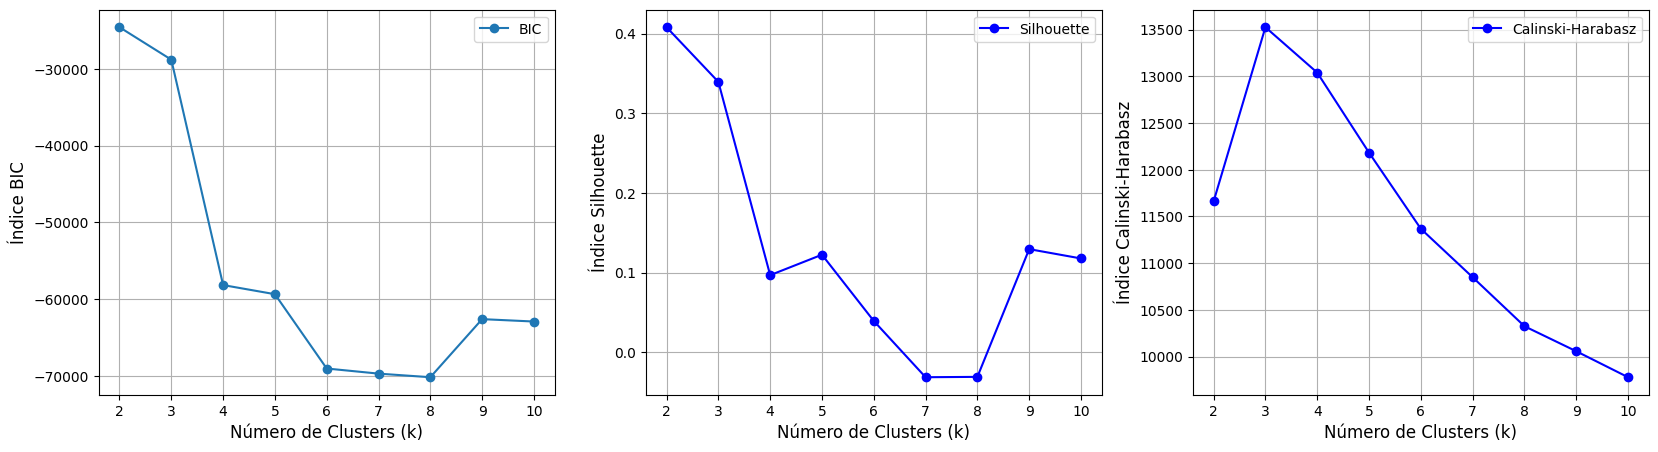

In [6]:
# Graficar los resultados
plt.figure(figsize=(20, 5))

# Gráfico de BIC
plt.subplot(1, 3, 1)
plt.plot(k_values, bic_scores, marker='o', linestyle='-', label="BIC")
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Índice BIC", fontsize=12)
plt.legend()
plt.grid(True)

# Gráfico de Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', label="Silhouette", color='b')
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Índice Silhouette", fontsize=12)
plt.legend()
plt.grid(True)

# Gráfico de Silhouette Score
plt.subplot(1, 3, 3)
plt.plot(k_values, ch_scores, marker='o', linestyle='-', label="Calinski-Harabasz", color='b')
plt.xlabel("Número de Clusters (k)", fontsize=12)
plt.ylabel("Índice Calinski-Harabasz", fontsize=12)
plt.legend()
plt.grid(True)

plt.show()

In [7]:
k_kmeans = 2

# Aplicar K-Means
kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
clusters = kmeans.fit_predict(datos_scaled)

# Asignar los clusters al DataFrame original
datos_scaled["Cluster KMeans"] = clusters

# Mostrar las primeras filas con la asignación de cluster
datos_scaled.head(20)

,Temperatura,Humedad Relativa,Índice UV,Cluster KMeans
6,0.461538,0.886598,0.000000,0
7,0.461538,0.948454,0.000000,0
8,0.461538,1.000000,0.000000,0
9,0.461538,1.000000,0.071429,0
10,0.487179,0.927835,0.142857,0
11,0.512821,0.783505,0.142857,0
12,0.564103,0.628866,0.428571,1
13,0.589744,0.494845,0.785714,1
14,0.641026,0.391753,0.857143,1
15,0.666667,0.329897,0.785714,1


In [16]:
# Aplicar GMM con el número óptimo de clusters
k_GMM = 3
gmm_final = GaussianMixture(n_components=k_GMM, random_state=42)
clusters_gmm = gmm_final.fit_predict(datos_scaled)

# Asignar los clusters al DataFrame original
datos_scaled["Cluster GMM"] = clusters_gmm
datos_scaled.head(20)


,Temperatura,Humedad Relativa,Índice UV,Cluster KMeans,Cluster GMM
6,0.461538,0.886598,0.000000,0,1
7,0.461538,0.948454,0.000000,0,1
8,0.461538,1.000000,0.000000,0,1
9,0.461538,1.000000,0.071429,0,1
10,0.487179,0.927835,0.142857,0,1
11,0.512821,0.783505,0.142857,0,1
12,0.564103,0.628866,0.428571,1,0
13,0.589744,0.494845,0.785714,1,0
14,0.641026,0.391753,0.857143,1,0
15,0.666667,0.329897,0.785714,1,0


In [9]:
datos['Cluster KMeans'] = "Noche"
datos['Cluster GMM'] = "Noche"
datos.loc[datos_scaled.index, "Cluster KMeans"] = datos_scaled["Cluster KMeans"]
datos.loc[datos_scaled.index, "Cluster GMM"] = datos_scaled["Cluster GMM"]
datos.head(24)


,Fecha,Generación,Temperatura,Humedad Relativa,Índice UV,Hora,Cluster KMeans,Cluster GMM
0,2022-09-01 00:00:00,0.000000,19,77,0,0,Noche,Noche
1,2022-09-01 01:00:00,0.000000,19,82,0,1,Noche,Noche
2,2022-09-01 02:00:00,0.000000,18,85,0,2,Noche,Noche
3,2022-09-01 03:00:00,0.000000,18,87,0,3,Noche,Noche
4,2022-09-01 04:00:00,0.000000,18,88,0,4,Noche,Noche
5,2022-09-01 05:00:00,0.000000,17,86,0,5,Noche,Noche
6,2022-09-01 06:00:00,0.000000,18,89,0,6,0,1
7,2022-09-01 07:00:00,6.584959,18,95,0,7,0,1
8,2022-09-01 08:00:00,560.422022,18,100,0,8,0,1
9,2022-09-01 09:00:00,7720.582326,18,100,1,9,0,1


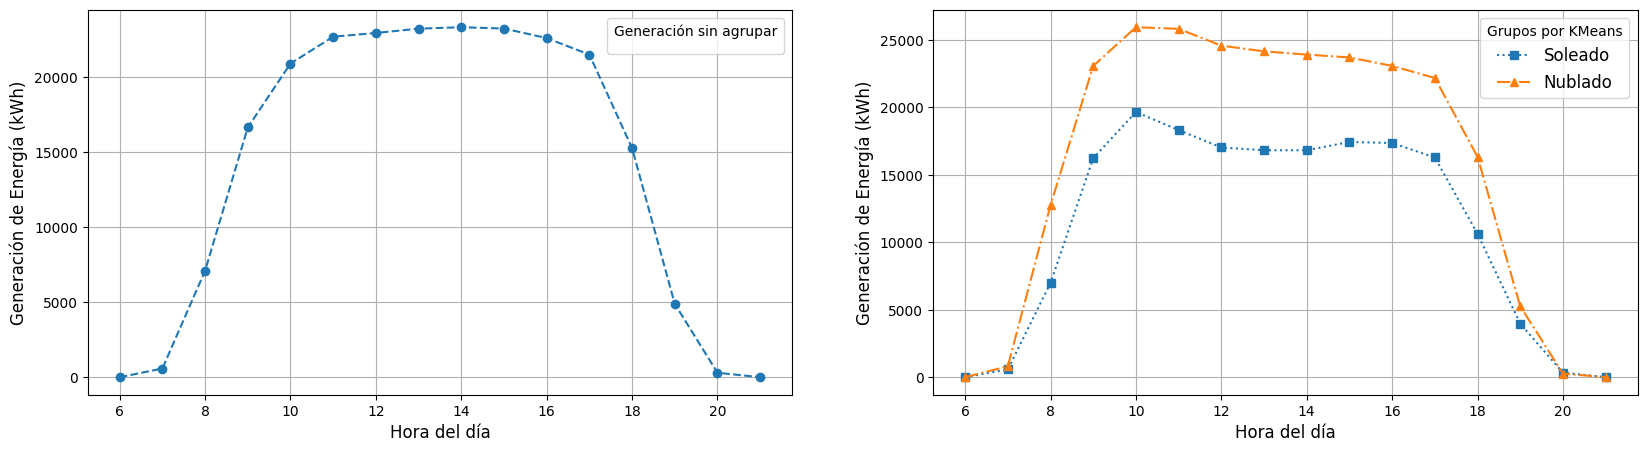

In [10]:
df_grouped = datos[(datos["Hora"] >= 6) & (datos["Hora"] <= 21)].groupby(['Hora'])['Generación'].mean().reset_index()

plt.figure(figsize=(20,5))

# Definir estilos para cada cluster
line_styles = ['dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 1))]
markers = ['o', 's', '^', 'D', 'x']
plt.subplot(1, 2, 1)
plt.plot(df_grouped['Hora'], df_grouped['Generación'], 
             linestyle='dashed', 
             marker='o')

# Configuración de la gráfica

plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Generación de Energía (kWh)", fontsize=12)
plt.legend(title="Generación sin agrupar", fontsize=12)
plt.grid(True)

df_grouped = datos[datos['Cluster KMeans'] != "Noche"].groupby(['Hora', 'Cluster KMeans'])['Generación'].mean().reset_index()

clusters = df_grouped['Cluster KMeans'].unique()

# Definir estilos para cada cluster
line_styles = ['dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 1))]
markers = ['s', '^', 'D', 'x']

plt.subplot(1, 2, 2)
# Dibujar una línea para cada cluster
for i, cluster in enumerate(clusters):
    if cluster == 0:
        label = 'Soleado'
    if cluster == 1:
        label = 'Nublado'
    subset = df_grouped[df_grouped['Cluster KMeans'] == cluster]
    plt.plot(subset['Hora'], subset['Generación'], 
             linestyle=line_styles[i % len(line_styles)], 
             marker=markers[i % len(markers)],
             label = label)

# Configuración de la gráfica
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Generación de Energía (kWh)", fontsize=12)
plt.legend(title="Grupos por KMeans", fontsize=12)
plt.grid(True)

# Mostrar la gráfica
plt.show()

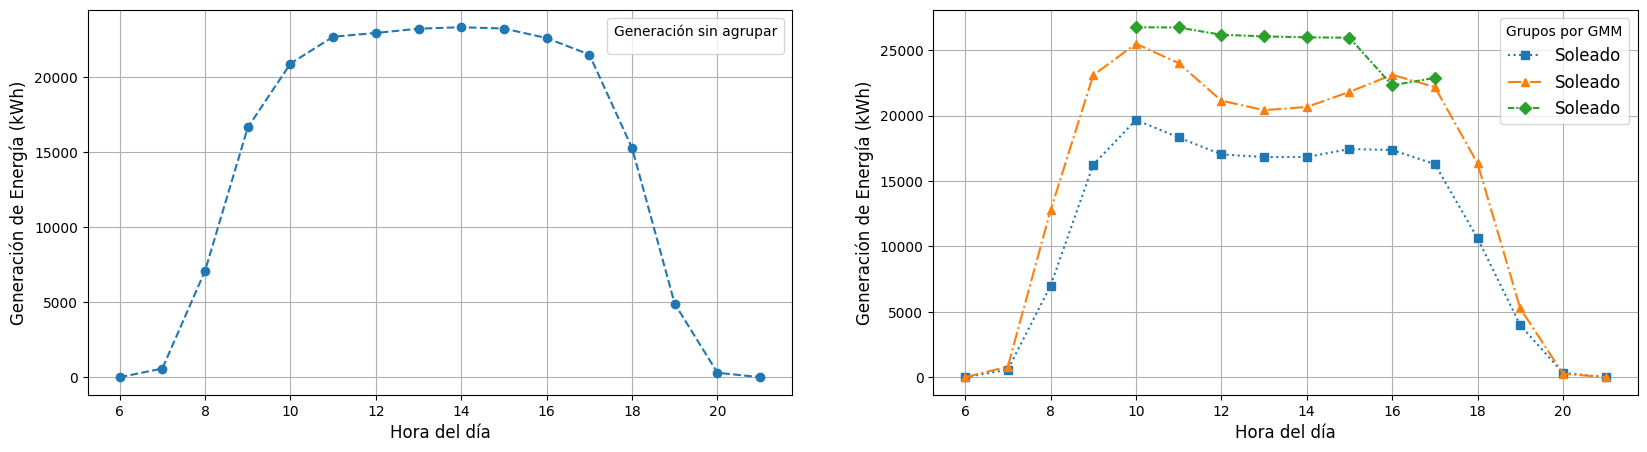

In [17]:
df_grouped = datos[(datos["Hora"] >= 6) & (datos["Hora"] <= 21)].groupby(['Hora'])['Generación'].mean().reset_index()

plt.figure(figsize=(20,5))

# Definir estilos para cada cluster
line_styles = ['dashed', 'dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 1))]
markers = ['o', 's', '^', 'D', 'x']
plt.subplot(1, 2, 1)
plt.plot(df_grouped['Hora'], df_grouped['Generación'], 
             linestyle='dashed', 
             marker='o')

# Configuración de la gráfica

plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Generación de Energía (kWh)", fontsize=12)
plt.legend(title="Generación sin agrupar", fontsize=12)
plt.grid(True)

df_grouped = datos[datos['Cluster GMM'] != "Noche"].groupby(['Hora', 'Cluster GMM'])['Generación'].mean().reset_index()

clusters = df_grouped['Cluster GMM'].unique()

# Definir estilos para cada cluster
line_styles = ['dotted', 'dashdot', (0, (3, 1, 1, 1)), (0, (5, 1))]
markers = ['s', '^', 'D', 'x']

plt.subplot(1, 2, 2)
# Dibujar una línea para cada cluster
for i, cluster in enumerate(clusters):
    if cluster == 0:
        label = 'Soleado'
    if cluster == 1:
        label = 'Lluvioso'
    if cluster == 2:
        label = 'Nublado'
    subset = df_grouped[df_grouped['Cluster GMM'] == cluster]
    plt.plot(subset['Hora'], subset['Generación'], 
             linestyle=line_styles[i % len(line_styles)], 
             marker=markers[i % len(markers)],
             label = label)

# Configuración de la gráfica
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Generación de Energía (kWh)", fontsize=12)
plt.legend(title="Grupos por GMM", fontsize=12)
plt.grid(True)

# Mostrar la gráfica
plt.show()

In [12]:
# Crear un diccionario con los nombres de los clusters
cluster_labels = {0: "Soleado", 1: "Nublado", "Noche": "Noche"}

# Reemplazar los valores en la columna "Cluster"
datos["Cluster KMeans"] = datos["Cluster KMeans"].map(cluster_labels)

# Crear un diccionario con los nombres de los clusters
cluster_labels = {0: "Soleado", 1: "Lluvioso", 2:"Nublado", "Noche": "Noche"}

# Reemplazar los valores en la columna "Cluster"
datos["Cluster GMM"] = datos["Cluster GMM"].map(cluster_labels)


In [13]:
datos.head(24)

,Fecha,Generación,Temperatura,Humedad Relativa,Índice UV,Hora,Cluster KMeans,Cluster GMM
0,2022-09-01 00:00:00,0.000000,19,77,0,0,Noche,Noche
1,2022-09-01 01:00:00,0.000000,19,82,0,1,Noche,Noche
2,2022-09-01 02:00:00,0.000000,18,85,0,2,Noche,Noche
3,2022-09-01 03:00:00,0.000000,18,87,0,3,Noche,Noche
4,2022-09-01 04:00:00,0.000000,18,88,0,4,Noche,Noche
5,2022-09-01 05:00:00,0.000000,17,86,0,5,Noche,Noche
6,2022-09-01 06:00:00,0.000000,18,89,0,6,Soleado,Lluvioso
7,2022-09-01 07:00:00,6.584959,18,95,0,7,Soleado,Lluvioso
8,2022-09-01 08:00:00,560.422022,18,100,0,8,Soleado,Lluvioso
9,2022-09-01 09:00:00,7720.582326,18,100,1,9,Soleado,Lluvioso


In [18]:
print(datos['Cluster KMeans'].value_counts())
print(datos['Cluster GMM'].value_counts())

Cluster KMeans
Nublado    6639
Noche      6098
Soleado    5553
Name: count, dtype: int64
Cluster GMM
Noche       6098
Lluvioso    5553
Nublado     4650
Soleado     1989
Name: count, dtype: int64


In [19]:
# También puedes guardarlo en Excel si prefieres
datos.to_excel("03_Clusterizacion_CTNET.xlsx", index=False)